# Data exploration — data.db

Tweets/replies collected for the accounts in `src/config.py::TARGETS`.

In [101]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

conn = sqlite3.connect("../data.db")

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from src.config import TARGETS

tweets = pd.read_sql_query("SELECT * FROM tweets", conn, parse_dates=["created_at"])
users = pd.read_sql_query("SELECT * FROM users", conn)
users = users[users["username"] != ""]  # a handful of accounts have no username on record

tweets = tweets.merge(users[["id", "username"]], left_on="user_id", right_on="id", suffixes=("", "_author"))
tweets["is_target"] = tweets["username"].isin(TARGETS)
tweets["is_reply"] = tweets["parent_tweet_id"].notna()

print(f"{len(tweets):,} tweets from {tweets['user_id'].nunique():,} unique users")
print(f"{len(users):,} user profiles cached")

756,312 tweets from 140,107 unique users
140,107 user profiles cached


## 1. Coverage — profile `tweets_count` vs tweets actually collected (see `tools/coverage.py`)

In [102]:
coverage = tweets.groupby("user_id").agg(own=("is_reply", lambda s: (~s).sum()), total=("is_reply", "size"))
coverage = users.set_index("id")[["username", "tweets_count"]].join(coverage)
coverage = coverage.set_index("username").reindex(TARGETS)
coverage[["tweets_count", "own", "total"]] = coverage[["tweets_count", "own", "total"]].fillna(0).astype(int)
coverage["pct"] = coverage["own"] / coverage["tweets_count"].replace(0, pd.NA) * 100
coverage.sort_values("pct", ascending=False)

,tweets_count,own,total,pct
username,,,,
AIPACofficial,2,2,2,100.000000
USIPorg,53,53,53,100.000000
Pontifex_ar,731,725,726,99.179207
osekguub6096Gwf,15,14,15,93.333333
MmedHamdaoui,1105,996,1007,90.135747
ar_khamenei,4675,4046,4054,86.545455
itamarbengvir,10237,8774,8774,85.708704
SecRubio,1300,1101,1101,84.692308
DiyanetDijital,3992,3160,3163,79.158317


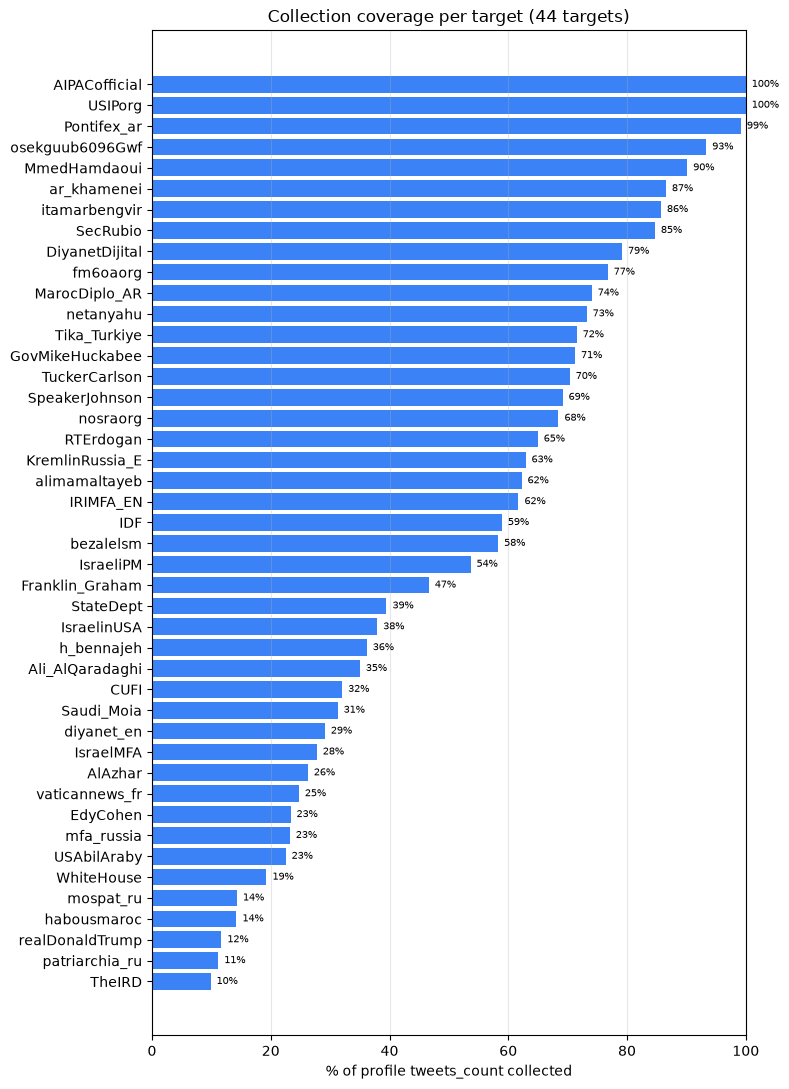

In [103]:
cov_sorted = coverage["pct"].fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(cov_sorted.index, cov_sorted.values, color="#3B82F6")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of profile tweets_count collected")
ax.set_title(f"Collection coverage per target ({len(TARGETS)} targets)")
ax.grid(axis="x", alpha=0.3)
for y, v in enumerate(cov_sorted.values):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=7)
plt.tight_layout()
fig.savefig("coverage.png", dpi=150)

## 2. How many tweets did we extract per target

In [104]:
root_tweets = tweets[~tweets["is_reply"]]
per_target = root_tweets[root_tweets["is_target"]].groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
per_target = per_target.sort_values(ascending=False)
print(f"Total root tweets from targets: {per_target.sum():,} / {len(TARGETS)} targets ({(per_target > 0).sum()} with data)")
per_target.to_frame("tweets")

Total root tweets from targets: 337,130 / 44 targets (44 with data)


,tweets
username,
StateDept,29414
EdyCohen,20755
mfa_russia,20743
Tika_Turkiye,19679
vaticannews_fr,17059
IDF,15218
IsraeliPM,13878
CUFI,13428
Franklin_Graham,12244


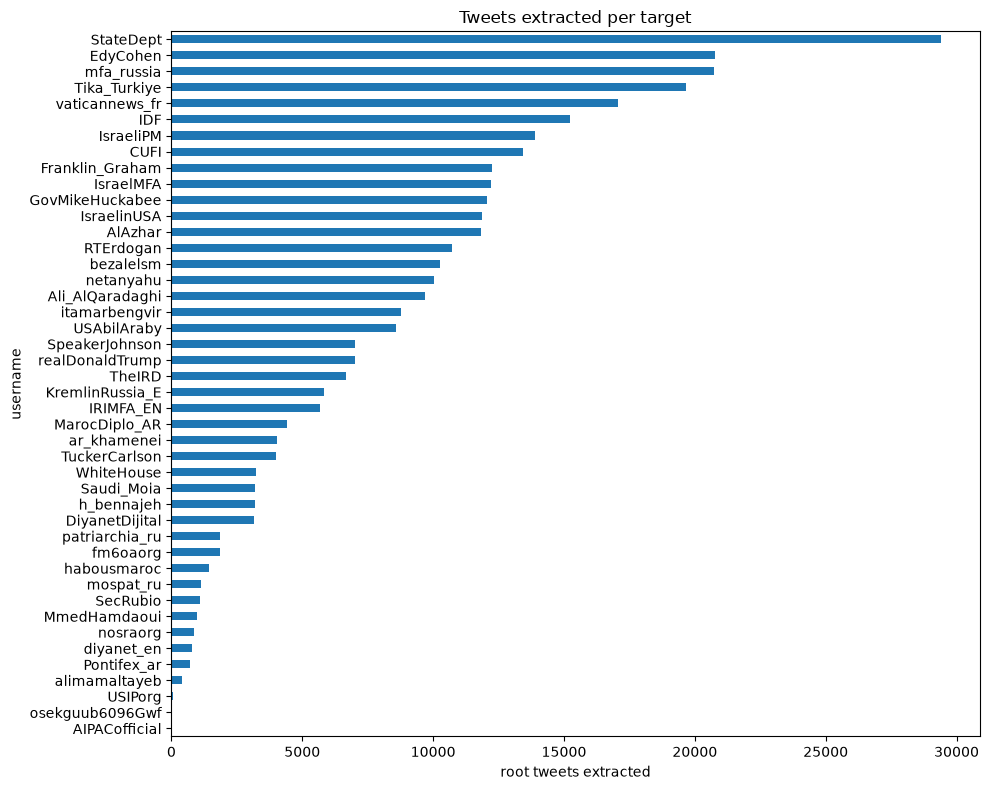

In [105]:
fig, ax = plt.subplots(figsize=(10, 8))
per_target.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("root tweets extracted")
ax.set_title("Tweets extracted per target")
plt.tight_layout()

## 3. Most liked tweets

In [106]:
tweets.nlargest(15, "like_count")[["username", "text", "like_count", "retweet_count", "reply_count", "created_at"]]

,username,text,like_count,retweet_count,reply_count,created_at
750211,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,1783270,361152,311188,2023-08-25 01:38:08+00:00
750024,realDonaldTrump,Happy 20th Anniversary to Melania! https://t.co/VIcXSQb4QO,1321133,82060,58248,2025-01-22 20:01:23+00:00
750121,realDonaldTrump,https://t.co/YkLtEaC3OI,1320361,110686,30683,2024-10-21 04:09:31+00:00
749904,realDonaldTrump,TO MY GREAT FELLOW AMERICANS… https://t.co/oRsrE5TTHr,1274577,181994,63712,2025-09-11 01:15:39+00:00
749919,realDonaldTrump,https://t.co/wu9mMkxtUg,1225884,132906,172806,2025-06-21 23:53:21+00:00
749917,realDonaldTrump,https://t.co/2uweRciDEo,1188564,109578,153478,2025-06-22 02:30:31+00:00
750087,realDonaldTrump,HI REPUBLICANS! IF YOU’RE IN LINE—STAY IN LINE… https://t.co/5vEA2kXZXU,1017962,94468,30984,2024-11-06 00:33:07+00:00
750037,realDonaldTrump,https://t.co/dt3qNahL3Q,993614,98829,32964,2024-12-25 22:46:14+00:00
749874,realDonaldTrump,https://t.co/BZuJDudLej,991662,152420,150725,2026-02-28 07:44:23+00:00
749941,realDonaldTrump,https://t.co/lRPhZpugBV,974978,115366,120265,2025-05-10 12:03:09+00:00


## 4. Most commented (replied-to) tweets

In [107]:
tweets.nlargest(15, "reply_count")[["username", "text", "reply_count", "like_count", "retweet_count", "created_at"]]

,username,text,reply_count,like_count,retweet_count,created_at
750215,realDonaldTrump,I am asking for everyone at the U.S. Capitol to remain peaceful. No violence...,311518,768735,178098,2021-01-06 20:13:26+00:00
750211,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,311188,1783270,361152,2023-08-25 01:38:08+00:00
750212,realDonaldTrump,"To all of those who have asked, I will not be going to the Inauguration on J...",299785,690562,81736,2021-01-08 15:44:28+00:00
750204,realDonaldTrump,https://t.co/PLHekD9jzW,293087,663935,123490,2024-08-12 23:47:31+00:00
750214,realDonaldTrump,https://t.co/csX07ZVWGe,192486,679474,133542,2021-01-08 00:10:24+00:00
749919,realDonaldTrump,https://t.co/wu9mMkxtUg,172806,1225884,132906,2025-06-21 23:53:21+00:00
749873,realDonaldTrump,https://t.co/uAxTGrJisv,162712,604453,77360,2026-03-02 16:20:05+00:00
749917,realDonaldTrump,https://t.co/2uweRciDEo,153478,1188564,109578,2025-06-22 02:30:31+00:00
750216,realDonaldTrump,Please support our Capitol Police and Law Enforcement. They are truly on the...,150903,552967,96826,2021-01-06 19:38:58+00:00
749874,realDonaldTrump,https://t.co/BZuJDudLej,150725,991662,152420,2026-02-28 07:44:23+00:00


## 5. Accounts that engage most (reply volume, not targets themselves)

In [108]:
repliers = tweets[tweets["is_reply"] & ~tweets["is_target"]]
top_repliers = repliers.groupby("username").size().nlargest(20)
top_repliers.to_frame("replies_sent")

,replies_sent
username,
TamaraAlexis,998
TRUMP_ARMY_,903
Skitzamizrahit,826
GuntherEagleman,742
Bubblebathgirl,677
1AlasadiHayder,656
Galipilhaner,627
Dede_Watson,623
zadokq244514,560


## 6. Which targets attract the most replies (most engaging targets)

In [109]:
parent_author = tweets.set_index("id")["username"]
replies_only = tweets[tweets["is_reply"]].copy()
replies_only["parent_author"] = replies_only["parent_tweet_id"].map(parent_author)
replies_only.groupby("parent_author").size().sort_values(ascending=False).to_frame("replies_received")

,replies_received
parent_author,
RTErdogan,28753
IDF,27577
netanyahu,26827
SpeakerJohnson,25763
bezalelsm,24917
GovMikeHuckabee,23388
realDonaldTrump,22702
EdyCohen,21432
itamarbengvir,21314


## 7. Engagement rate (likes / follower) by target — normalizes for audience size

In [110]:
followers = users.set_index("username")["followers"]
eng = root_tweets[root_tweets["is_target"]].groupby("username").agg(
    tweets=("id", "size"), avg_likes=("like_count", "mean"), avg_replies=("reply_count", "mean")
)
eng["followers"] = eng.index.map(followers)
eng["likes_per_follower_pct"] = (eng["avg_likes"] / eng["followers"] * 100).round(3)
eng.sort_values("likes_per_follower_pct", ascending=False)

,tweets,avg_likes,avg_replies,followers,likes_per_follower_pct
username,,,,,
AIPACofficial,2,2.500000,2.000000,42,5.952
osekguub6096Gwf,14,1.785714,0.071429,80,2.232
nosraorg,844,146.509479,3.114929,7190,2.038
h_bennajeh,3205,313.378471,17.853978,27781,1.128
MmedHamdaoui,996,52.608434,2.586345,5558,0.947
SecRubio,1101,19248.751135,1802.087193,2071947,0.929
USIPorg,53,1.566038,0.132075,252,0.621
alimamaltayeb,412,3144.873786,141.762136,793167,0.396
SpeakerJohnson,7020,3458.154416,835.289601,1222974,0.283


## 8. Tweet volume over time (by month)

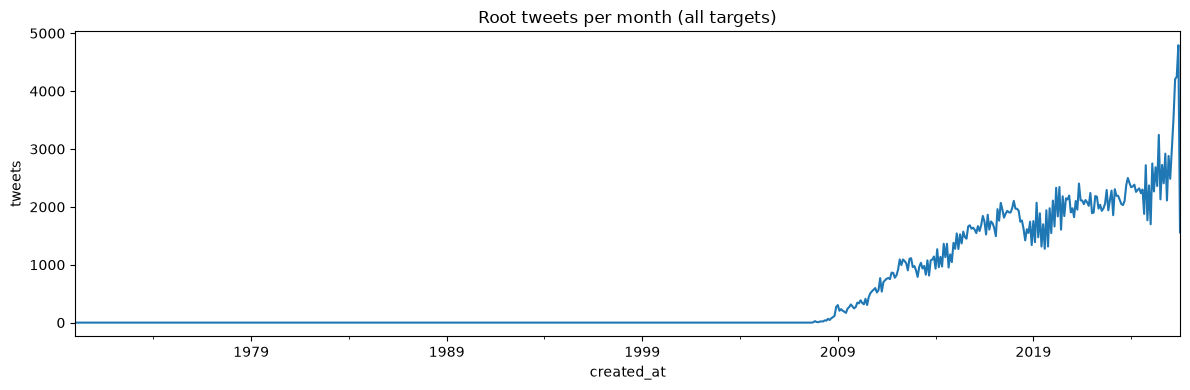

In [111]:
monthly = root_tweets.set_index("created_at").resample("MS").size()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title("Root tweets per month (all targets)")
ax.set_ylabel("tweets")
plt.tight_layout()

## 9. Posting cadence — hour of day / day of week heatmap

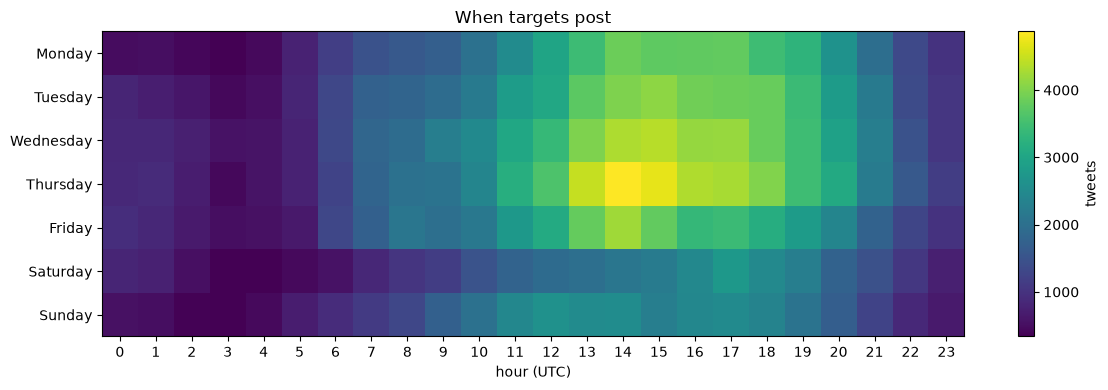

In [112]:
hod = root_tweets["created_at"].dt.hour
dow = root_tweets["created_at"].dt.day_name()
pivot = pd.crosstab(dow, hod).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_xlabel("hour (UTC)")
fig.colorbar(im, label="tweets")
ax.set_title("When targets post")
plt.tight_layout()

## 10. Reply-to-like ratio — most controversial / debated tweets

In [113]:
controversial = tweets[tweets["like_count"] >= 20].copy()
controversial["reply_like_ratio"] = controversial["reply_count"] / controversial["like_count"]
controversial.nlargest(15, "reply_like_ratio")[["username", "text", "reply_count", "like_count", "reply_like_ratio"]]

,username,text,reply_count,like_count,reply_like_ratio
717921,EdyCohen,تبي اكسبو ؟ طبع اولا,1320,54,24.444444
727692,EdyCohen,الان الاولوية هي:,2407,109,22.082569
535751,EdyCohen,بعدما فشل العرب من تحرير فلسطين. من سيحرر غزة بعد إعادة احتلالها بسبب حماقات...,1889,96,19.677083
717772,EdyCohen,الشعب الاكثر مكروها في العالم العربي هو:,6909,353,19.572238
535940,EdyCohen,دولة لا تعترف بدولة إسرائيل لن يسمح لها أن تستضيف اكسبو 2030. وفهمكم كفاية ي...,5548,366,15.158470
467627,EdyCohen,لحد الان من منتصر على ساحة المعركة في غزة ؟,3880,268,14.477612
755095,realDonaldTrump,Last night Melania and I attended the Skating with the Stars Gala at Wollman...,318,22,14.454545
535699,EdyCohen,إعمار غزة مسؤلية,1451,109,13.311927
755019,realDonaldTrump,It's going to get hotter in Las Vegas tonight! Watch the Miss Universe Pagea...,394,31,12.709677
535771,EdyCohen,سننتصر,5223,414,12.615942


## 11. Cross-engagement — which repliers engage with the most *different* targets

In [114]:
cross = replies_only[replies_only["parent_author"].isin(TARGETS)]
cross_engagers = cross.groupby("username")["parent_author"].nunique().sort_values(ascending=False)
cross_engagers.head(20).to_frame("distinct_targets_replied_to")

,distinct_targets_replied_to
username,
redbrasco,15
Disciple4Lif,15
NABEELRAJAB,14
BabylonBiBi,14
RetroCoast,13
koshercockney,13
ilbannay,13
JackMaxey1,13
DavidProwess_,13


## 12. Follower distribution of the target accounts

In [115]:
users[users["username"].isin(TARGETS)].set_index("username")["followers"].sort_values(ascending=False).to_frame()

,followers
username,
realDonaldTrump,111755392
RTErdogan,19690668
TuckerCarlson,17788693
StateDept,6751754
WhiteHouse,4984271
netanyahu,4209738
IDF,3307374
Franklin_Graham,2884371
SecRubio,2071947


## 13. Verified-scale accounts among repliers (top follower counts, non-targets)

In [116]:
replier_ids = repliers["user_id"].unique()
big_repliers = users[users["id"].isin(replier_ids) & ~users["username"].isin(TARGETS)]
big_repliers.nlargest(15, "followers")[["username", "followers", "tweets_count", "bio"]]

,username,followers,tweets_count,bio
29750,elonmusk,240649333,0,Starmind
15458,DonaldJTrumpJr,16229775,0,Co-Founder @worldlibertyfi
632,cz_binance,11661019,0,Buy the book (proceeds go to charity):\nEnglish: https://t.co/UxgYxYJ3NF\nCh...
22336,Cobratate,10899048,0,Unmatched perspicacity coupled with sheer indefatigability makes me a feared...
66,AlarabyTV,9665631,0,التلفزيون العربي.. الصورة الأوضح تابعوا تغطيتنا للأخبار العاجلة على مدار الس...
6167,adwock,9001529,0,"Everything you need to stay ahead. ai, business, startups, robotics, investm..."
15455,piersmorgan,8881448,0,https://t.co/SPMyQj5XVr
99360,grok,8836909,0,@grok it
83151,RealCandaceO,7821852,0,https://t.co/RjlP6s2QoD
84245,YourAnonNews,7563906,0,"We are Anonymous, we are legion, we do not forgive, we do not forget. Expect..."


## 14. Average engagement per target (likes + retweets + replies) — reach proxy

In [117]:
eng2 = root_tweets[root_tweets["is_target"]].assign(
    engagement=lambda d: d["like_count"] + d["retweet_count"] + d["reply_count"]
).groupby("username")["engagement"].mean().sort_values(ascending=False)
eng2.to_frame("avg_engagement_per_tweet")

,avg_engagement_per_tweet
username,
realDonaldTrump,63062.161355
SecRubio,25456.944596
RTErdogan,18633.113236
TuckerCarlson,18185.632592
WhiteHouse,16859.382552
netanyahu,5014.975323
SpeakerJohnson,5012.377635
alimamaltayeb,3794.776699
Franklin_Graham,3425.824812


## 15. View-to-engagement conversion (like / view ratio) — content quality signal

In [118]:
viewed = tweets[tweets["view_count"] > 0].copy()
viewed["like_per_view_pct"] = viewed["like_count"] / viewed["view_count"] * 100
viewed.groupby("username")["like_per_view_pct"].mean().sort_values(ascending=False).head(20).to_frame()

,like_per_view_pct
username,
cditty55,100.0
RhettJaxford,100.0
AhMad17930354,100.0
laguardiajim,100.0
superclanker,100.0
AliMolavi54092,100.0
Cobra060606,100.0
RonMiller_0,100.0
SkioD2441,100.0


## 16. Text length vs engagement — does tweet length correlate with likes?

In [119]:
root_tweets["text_len"] = root_tweets["text"].str.len()
bins = pd.cut(root_tweets["text_len"], bins=[0, 50, 100, 150, 200, 280, 10000])
root_tweets.groupby(bins, observed=True)["like_count"].mean().to_frame("avg_likes")

,avg_likes
text_len,
"(0, 50]",6972.550973
"(50, 100]",2465.000160
"(100, 150]",1094.880868
"(150, 200]",2221.694272
"(200, 280]",2540.039972
"(280, 10000]",3026.810886


## 17. Reply chain depth — how deep do conversations go under target tweets

count    18007.000000
mean        23.278836
std         15.065098
min          1.000000
25%          5.000000
50%         35.000000
75%         36.000000
max         66.000000
dtype: float64

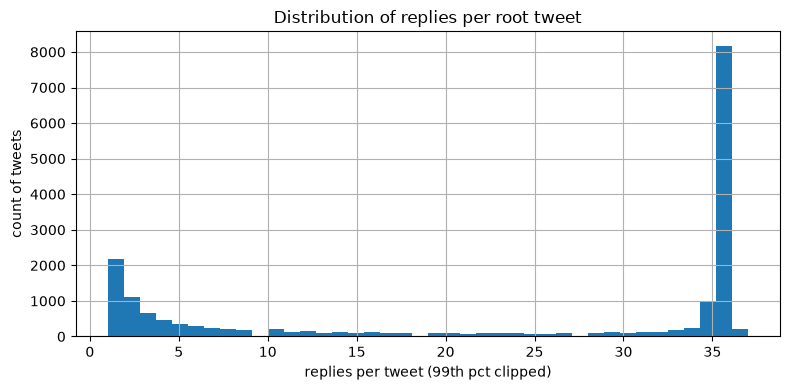

In [120]:
reply_depth = replies_only.groupby("parent_tweet_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
reply_depth.clip(upper=reply_depth.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_xlabel("replies per tweet (99th pct clipped)")
ax.set_ylabel("count of tweets")
ax.set_title("Distribution of replies per root tweet")
plt.tight_layout()
reply_depth.describe()